# 2. k-means Clustering with Semidefinite Programming - 45 points

Clustering is and unsupervised machine learning problem in which we try to partition a given dataset into $k$ subsets based on distance between data points or similarity among them. The goal is to find $k$ centers and to assign each data point to one of the centers such that the sum of the square distances between them are minimal [1]. This problem is known to be NP-hard. 

## Clustering problem
Given a set of $n$ points in a $d-$dimensional Euclidean space, denoted by
\begin{equation*}
S = \{ \mathbf{s}_i = (s_{i1}, \cdots, s_{id})^\top~\in \mathbb{R}^d ~~ i = 1, \cdots, n\}
\end{equation*}
find an assignment of the $n$ points into $k$ disjoint clusters $\mathcal{S} = (S_1, \cdots, S_k)$ whose centers are $\mathbf{c}_j(j = 1, \cdots, k)$ based on the total sum of squared Euclidean distances from each point $\mathbf{s}_i$ to its assigned cluster centroid $\mathbf{c}_i$, i.e.,
\begin{equation}
f(S,\mathcal{S}) = \sum_{j=1}^k\sum_{i=1}^{|S_j|}\|\mathbf{s}_i^{j} - \mathbf{c}_j \|^2,
  
\end{equation}
where $|S_j|$ is the number of points in $S_j$, and $\mathbf{s}_i^{j} $ is the $i^{th}$ point in $S_j$.

## Lloyd's algorithm for k-means



  **1.** Choose initial cluster centers $\mathbf{c}_1, \mathbf{c}_2, \cdots , \mathbf{c}_k$
  
  **2.** Repeat until convergence:
  $$\begin{cases}
  \text{Assignment step: }~~  \mathbf{s}_i ~~\text{belongs to cluster } j\text{, where} j := \text{argmin}_{j \in [1,k]} \|\mathbf{s}_i-\mathbf{c}_j\|   \\
  \text{Update each cluster center: }~~~~~~~~ \mathbf{c}_j = \frac 1{|S_j|} \sum_{i=1}^{|S_j|} \mathbf{s}_i^{j} \\
  \end{cases}$$


Note that the algorithm converges to local optimal points, so
\eqref{eq:cluster} can be arbitrarily bad depending on the
initialization of the cluster centers.


 **SDP relaxation of the problem:** The work (Peng & Wei, 2007)
proposes an SDP-relaxation to approximately solve the aforementioned
model-free $k-$means clustering problem. The resulting optimization
problem (See section (2) of (Peng & Wei, 2007) for details of this
    relaxation and Lecture 14 for a brief introduction.) takes the standard semidefinite programming form

$$\mathbf{X}^\star \in \arg \min_{ \mathbf{X} } \bigg\{ \langle \boldsymbol{C}, \mathbf{X} \rangle : ~\underbrace{\mathbf{X} \mathbf{1} =  \mathbf{1}}_{A_1(\mathbf{X}) = b_1},\underbrace{~\mathbf{X}^{\top} \mathbf{1} = \mathbf{1}}_{A_2(\mathbf{X}) = b_2},~\underbrace{\mathbf{X} \geq 0}_{B(\mathbf{X}) \in \mathcal{K}},~\underbrace{\mathrm{Tr}(\mathbf{X}) \leq \kappa, ~\mathbf{X} \in \mathbb{R}^{p\times p} ,~\mathbf{X}\succeq 0 }_{\mathcal{X}} \bigg\},
  $$ 
where $C \in \mathbb{R}^{p \times p}$ is the
Euclidean distance matrix between the data points.
$\mathrm{Tr}(\mathbf{X}) \leq \kappa$ enforces approximately low-rank
solutions, the linear inclusion constraint $\mathbf{X} \geq 0$ is element-wise
nonnegativity of ${\mathbf{X}}$, the linear equality constraints
$\mathbf{X}\mathbf{1} = \mathbf{1}$ and $\mathbf{X}^{\top} \mathbf{1} = \mathbf{1}$
require row and column sums of $\mathbf{X}$ to be equal to 1's, and
$\mathbf{X} \succeq 0$ means that $\mathbf{X}$ is positive semi-definite. Recall that
$\mathrm{Tr}(\mathbf{X}) = \|\mathbf{X}\|_\ast$ for any positive semi-definite matrix
$\mathbf{X}$.

The SDP in Problem 1 can be reformulated as 
$$
\min_{\mathbf{X} \in \mathcal{X}}~~~ f(\mathbf{X}) + g_1(A_1(\mathbf{X})) + g_2(A_2(\mathbf{X})) \qquad\text{subject to}\qquad B(\mathbf{X}) \in \mathcal{K},   $$ 
where $f(\mathbf{X}) = \langle  \boldsymbol{C}, \mathbf{X} \rangle$ is a
smooth convex function, $g_1=\delta_{\{b_1\}}(\cdot)$ is the indicator
function of singleton $\{b_1\}$, $g_2=\delta_{\{b_2\}}(\cdot)$ is the
indicator function of singleton $\{b_2\}$ and ${\mathcal{K}}$ is the
positive orthant for which computing the projection is easy.

## 2.1 Theory - 25 points

#### Question 2.1.1 (2 pts) 
Would Frank-Wolfe be a valid approach to solve this problem? Elaborate on your answer. 

<font color=‘blue’>
    
No, Frank-Wolfe is not a valid approach for this problem.

The Frank-Wolfe algorithm works by linearizing the objective function at the current iterate $\mathbf{X}_k$ and minimizing this linearization over the feasible set. Since $f(\mathbf{X})$ is already linear, its gradient $\nabla f(\mathbf{X}) = \boldsymbol{C}$ is constant. The linear approximation is identical to the original objective.

In the sequel, we will attempt to solve this problem with the HomotopyCGM method (**Algorithm 1**) proposed in
(Yurtsever et al., 2018) to handle the non-smooth problems with a
conditional gradient based method.
Another option for solving this problem is PD3O
method (**Algorithm 2**).

#### Question 2.1.2 (3 pts) Characterizing the domain

Show that the domain $\mathcal{X} = \{\mathbf{X}: \mathrm{Tr}(\mathbf{X}) \leq \kappa,~\mathbf{X} \in \mathbb{R}^{p\times p} ,~\mathbf{X} \succeq 0\}$ is a convex set. For this purpose, apply the definition of set convexity.


<font color=‘blue’>
    
Answer:

Let's assume $\mathbf{A, B} \in \mathcal{X}$ and $\theta \in [0,1]$, then by the definition of set convexity we need to show that $\mathbf{C}=\theta \mathbf{A} + (1-\theta)\mathbf{B}$ satisfies $\mathbf{C}\in\mathcal{X}$.

First, we are going to show that $\mathcal{C}$ is positive semi-definite. Given an arbitrary vector \mathbf{v}:
$$
\mathbf{v}^\top \mathbf{C} \mathbf{v} = \mathbf{v}^\top (\theta \mathbf{A} + (1-\theta)\mathbf{B}) \mathbf{v} = \theta (\mathbf{v}^\top \mathbf{A} \mathbf{v}) + (1-\theta) (\mathbf{v}^\top \mathbf{B} \mathbf{v}).
$$

Since $\mathbf{A}, \mathbf{B} \succeq 0$, we know that $\mathbf{v}^\top \mathbf{A} \mathbf{v} \geq 0$ and $\mathbf{v}^\top \mathbf{B} \mathbf{v} \geq 0$. Also, since $\theta \in [0, 1]$, both $\theta$ and $(1-\theta)$ are non-negative.
Therefore, we have $\mathbf{v}^\top \mathbf{C} \mathbf{v} \geq 0$, which means $\mathcal{C} \succeq 0$.

Then, we must show that $\mathrm{Tr}(\mathbf{C}) \leq \kappa$:
$$
\mathrm{Tr}(\mathbf{C}) = \mathrm{Tr}(\theta \mathbf{A} + (1-\theta)\mathbf{B}) = \theta \mathrm{Tr}(\mathbf{A}) + (1-\theta)\mathrm{Tr}(\mathbf{B}) \leq \theta \kappa + (1-\theta)\kappa = \kappa.
$$
Since the convex combination $\mathbf{C} \in \mathcal{X}$, the domain $\mathcal{X}$ is a convex set.

#### Question 2.1.3  (8 pts) Gradient of the penalized objective

Given a linear inclusion constraint $Tx \in \mathcal{Y}$,
the corresponding quadratic penalty function is given by
$$\text{QP}_\mathcal{Y}(x) = \text{dist}^2(Tx, \mathcal{Y}) = \min_{y \in \mathcal{Y}} \| y-Tx\|^2.$$
Write down the constraints in (Equation 2) in
the quadratic penalty form. 

Write down the penalized objective based on the formulation in Lecture 13 with penalty parameter $\beta$.



<font color=‘blue’>

$$
\text{QP}_{1}(\mathbf{X}) = \| \mathbf{X}\mathbf{1} - \mathbf{1} \|_2^2
$$
$$
\text{QP}_{2}(\mathbf{X}) = \| \mathbf{X}^{\top}\mathbf{1} - \mathbf{1} \|_2^2
$$    
$$
\text{QP}_{\mathcal{K}}(\mathbf{X}) = \text{dist}^2(\mathbf{X}, \mathcal{K}) = \| \mathbf{X} - \mathcal{P}_{\mathcal{K}}(\mathbf{X}) \|_F^2
$$
where $\mathcal{P}_{\mathcal{K}}(\mathbf{X}) = [\mathbf{X}]_+$ is the projection onto the positive orthant (setting negative entries to 0).
$$
\text{obj}(\mathbf{X}) = \langle \boldsymbol{C}, \mathbf{X} \rangle + \frac{\beta}{2} \left( \| \mathbf{X}\mathbf{1} - \mathbf{1} \|_2^2 + \| \mathbf{X}^{\top}\mathbf{1} - \mathbf{1} \|_2^2 + \text{dist}^2(\mathbf{X}, \mathcal{K}) \right)\qquad\text{where }\mathbf{X} \in \mathcal{X}
$$ 

#### Question 2.1.4 (7 pts) 

Derive the gradient of the penalized objective explicitly  by deriving the gradient and projection specific to (Equation 2) -->. 
(Hint: You can write
$\text{dist}^2(Tx, \mathcal{Y}) = \| y^\ast - Tx \|^2$, where
$y^\ast = \arg \min _{y\in \mathcal{Y}} \| y - Tx \|^2$. and take
the derivative with respect to $\mathbf{X}$ without worrying about
$y^\ast$ depending on $\mathbf{X}$, thanks to Danskin's theorem.

<font color=‘blue’>
Term 1: $f(\mathbf{X}) = \langle \mathbf{C}, \mathbf{X} \rangle$, so the gradient of a linear inner product is simply the coefficient matrix $\mathbf{C}$. 

Term 2: $f_2(\mathbf{X}) = \frac{\beta}{2} \| \mathbf{X}\mathbf{1} - \mathbf{1} \|_2^2$, using the chain rule:
$$
d(f_2) = \beta (\mathbf{X}\mathbf{1} - \mathbf{1})^\top d(\mathbf{X}\mathbf{1}) = \beta (\mathbf{X}\mathbf{1} - \mathbf{1})^\top (d\mathbf{X}) \mathbf{1} = \beta \mathrm{Tr}((\mathbf{X}\mathbf{1} - \mathbf{1})^\top d\mathbf{X}\mathbf{1}) = \mathrm{Tr}(\mathbf{1} (\mathbf{X}\mathbf{1} - \mathbf{1})^\top d\mathbf{X})
$$
Thus the gradient is $\beta (\mathbf{X}\mathbf{1} - \mathbf{1})\mathbf{1}^\top$. 

Term3 is quite similar. We can get: 
$$
\nabla f_3(\mathbf{X}) = \beta \mathbf{1} (\mathbf{X}^{\top}\mathbf{1} - \mathbf{1})^{\top}
$$

Term 4: $f_4(\mathbf{X}) = \frac{\beta}{2} \text{dist}^2(\mathbf{X}, \mathcal{K}) = \frac{\beta}{2} \min_{\mathbf{Y} \in \mathcal{K}} \| \mathbf{Y} - \mathbf{X} \|_F^2$. Using the Hint: To find the gradient of $\frac{1}{2} \min_{\mathbf{Y} \in \mathcal{K}} \| \mathbf{Y} - \mathbf{X} \|^2$, we can treat the optimal projection $\mathbf{Y}^*$ as a constant.Let $\mathbf{Y}^* = \mathcal{P}_{\mathcal{K}}(\mathbf{X}) = \max(0, X_{ij}) = [\mathbf{X}]_+$ be the projection of $\mathbf{X}$ onto the set $\mathcal{K}$. Therefore:$$\nabla f_4(\mathbf{X}) = \beta (\mathbf{X} - \mathcal{P}_{\mathcal{K}}(\mathbf{X})) = \beta (\mathbf{X} - [\mathbf{X}]_+)$$
Summing the gradients of the four terms, we get the explicit gradient of the penalized objective:
$$
\nabla \text{obj}(\mathbf{X}) = \boldsymbol{C} + \beta \left( (\mathbf{X}\mathbf{1} - \mathbf{1})\mathbf{1}^\top + \mathbf{1}(\mathbf{X}^{\top}\mathbf{1} - \mathbf{1})^\top + (\mathbf{X} - [\mathbf{X}]_+) \right)
$$

#### Question 2.1.5 (5 pts) 

The algorithm PD3O (Yan, Ming, 2018) can be used to solve the problem
$$\min_x f(x) + g(A(x)) + h(x)$$ 
where,
$f(x) = \langle \boldsymbol{C}, x \rangle$ and
$h(x) = \delta_{\mathcal{X}}(x)$. Moreover,
$g(A(x)) = g_1(A_1 (x)) + g_2(A_2 (x)) + \delta_{\mathcal{K}}(Bx)$ for a
suitably defined $g$ and $A$.
#### PD3O splitting method
  ------------------------------------------------------------------------------------------------------------------------------
  **1.** Choose $x^0 \in\mathcal{X}, y^0\in\mathbb{R}^{2p+p^2}$ and $\tau, \sigma >  0$
  
  **2.** For $k=1, 2, \ldots$ perform:
  $$\begin{cases}
  x^{k+1} &= \mathrm{prox}_{\tau h}(x^k - \tau (\nabla f(x^k) + A^\top y^k)) \\
  \tilde x^{k+1} &= 2x^{k+1} - x^k +  \tau \nabla f(x^k)-  \tau \nabla f(x^{k+1})\\
  y^{k+1} &= \mathrm{prox}_{\sigma g^\ast}(y^k + \sigma A(\tilde x^{k+1}))
  \end{cases}$$ 
  
  **3.Output: $~x^k$**
  
  ---------------------------------------------------------------------------------------------------------------------------------


In particular, define
$$\begin{aligned} 
z  = \begin{bmatrix} z_1 \\ z_2 \\ z_3 \end{bmatrix} = \begin{bmatrix}A_1x \\ A_2 x \\ Bx \end{bmatrix},~~~~~A = \begin{bmatrix} A_1 \\ A_2 \\ B \end{bmatrix}~~~~\Rightarrow~~~~~z= A(x),
\end{aligned} $$
and
$$ 
g(z) = \delta_{\{b_1\}}(z_1) + \delta_{\{b_2\}}(z_2) + \delta_\mathcal{K}(z_3).$$

Using the definitions we used for $g$ and $A$
in (Definition of A)
and (Definition of g), show that the $y^{k+1}$ update step of
PD3O can be written in the form
$$y^{k+1} := \begin{bmatrix} y_1^{k+1} \\ y_2^{k+1} \\ y_3^{k+1} \end{bmatrix} = \begin{bmatrix} y_1^k \\ y_2^k \\ y_3^k \end{bmatrix} +\sigma \begin{bmatrix} A_1\tilde x^{k+1} - b_1 \\ A_2\tilde x^{k+1} - b_2 \\ B\tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(\sigma^{-1}y_3^k + B\tilde x^{k+1}) \end{bmatrix},$$
and
$$A^\top y^{k+1} = A^\top y^k + \sigma (A_1^\top(A_1 (\tilde x^{k+1}) - b_1) + A_2^\top (A_2 (\tilde x^{k+1}) - b_2) +B^\top(B\tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(\sigma^{-1}y^k_3 + B\tilde x^{k+1}))),$$
where the vector $y$ in the dual domain can be written in the form
$y = [y_1~,~y_2~,~y_3]^\top$ with $y_1, y_2\in\mathbb{R}^p$ and
$y_3 \in\mathbb{R}^{p^2}$ (see
also (Definition of A)).

**Hint**: Use Moreau's decomposition to write the update using
$\mathrm{prox}_{g}$ instead of $\mathrm{prox}_{g^\ast}$. In
particular
$$y^{k+1} = \mathrm{prox}_{\sigma g^\ast}(y^k + \sigma A(\tilde x^{k+1})) = y^k + \sigma A( \tilde x^{k+1}) - \sigma \mathrm{prox}_{\sigma^{-1} g}(\sigma^{-1}y^k + A(\tilde x^{k+1})) \\
%&= y^k + \sigma (A_1\tilde x^{k+1} + A_2\tilde x^{k+1} + \tilde x^{k+1}) - \sigma (b_1+b_2+\mathrm{proj}_\mathcal{K}(\sigma^{-1}y^k + \tilde x^{k+1}))$$
The remaining steps are to
use (Definition of A) and find how to compute
$\mathrm{prox}_{g}$ when $g$ is in the decomposed form given
in (Definition of g).

<font color=‘blue’>
    
The generic update step for the dual variable in PD3O is:
$$
y^{k+1} = \mathrm{prox}_{\sigma g^\ast}(v^k)
$$
where $v^k = y^k + \sigma A(\tilde x^{k+1})$. 

Using the Moreau decomposition: 
$$
\mathrm{prox}_{\sigma g^*}(v) = v - \sigma \mathrm{prox}_{\sigma^{-1} g}(\sigma^{-1} v)
$$
Substituting $v^k$:
$$
\begin{aligned}
y^{k+1} &= (y^k + \sigma A(\tilde x^{k+1})) - \sigma \mathrm{prox}_{\sigma^{-1} g}\left( \sigma^{-1}(y^k + \sigma A(\tilde x^{k+1})) \right) \\
&= y^k + \sigma A(\tilde x^{k+1}) - \sigma \mathrm{prox}_{\sigma^{-1} g}\left( \sigma^{-1}y^k + A(\tilde x^{k+1}) \right)
\end{aligned}
$$
Let's define $u$:
$$
u = \sigma^{-1}y^k + A(\tilde x^{k+1})
$$
The function $g(z)$ and the operator $A(x)$ are separable into three blocks corresponding to the constraints:
$$
g(z) = \delta_{\{b_1\}}(z_1) + \delta_{\{b_2\}}(z_2) + \delta_{\mathcal{K}}(z_3)
$$
$$
A(x) = \begin{bmatrix} A_1 \\ A_2 \\ B \end{bmatrix} x
$$
Consequently, the vector $u$ also splits into three components:
$$
u = 
\begin{bmatrix} 
u_1 \\ u_2 \\ u_3 
\end{bmatrix} = 
\begin{bmatrix} 
\sigma^{-1}y_1^k + A_1 \tilde x^{k+1} \\ \sigma^{-1}y_2^k + A_2 \tilde x^{k+1} \\ \sigma^{-1}y_3^k + B \tilde x^{k+1} 
\end{bmatrix}
$$
Since $g$ is a sum of independent functions, its proximal operator applies component-wise. Recall that the proximal operator of an indicator function $\delta_S$ is the projection $\mathrm{proj}_S$.

Block 1 ($z_1$): $g_1 = \delta_{\{b_1\}}$. The set is a singleton $\{b_1\}$.
$$
\mathrm{prox}_{\sigma^{-1} g_1}(u_1) = \mathrm{proj}_{\{b_1\}}(u_1) = b_1
$$
Block 2 ($z_2$): $g_2 = \delta_{\{b_2\}}$. The set is a singleton $\{b_2\}$.
$$
\mathrm{prox}_{\sigma^{-1} g_2}(u_2) = \mathrm{proj}_{\{b_2\}}(u_2) = b_2
$$
Block 3 ($z_3$): $g_3 = \delta_{\mathcal{K}}$. The set $\mathcal{K}$ is the positive orthant.
$$
\mathrm{prox}_{\sigma^{-1} g_3}(u_3) = \mathrm{proj}_{\mathcal{K}}(u_3)
$$
Now substitute these proximal results back into the decomposition formula:
$$
y^{k+1} = \begin{bmatrix} y_1^k \\ y_2^k \\ y_3^k \end{bmatrix} + \sigma \begin{bmatrix} A_1 \tilde x^{k+1} \\ A_2 \tilde x^{k+1} \\ B \tilde x^{k+1} \end{bmatrix} - \sigma \begin{bmatrix} b_1 \\ b_2 \\ \mathrm{proj}_{\mathcal{K}}(u_3) \end{bmatrix}
$$
Grouping terms by index:
$$
\begin{aligned}
y_1^{k+1} &= y_1^k + \sigma (A_1 \tilde x^{k+1} - b_1)\\
y_2^{k+1} &= y_2^k + \sigma (A_2 \tilde x^{k+1} - b_2)\\
y_3^{k+1} &= y_3^k + \sigma (B \tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(\sigma^{-1}y_3^k + B \tilde x^{k+1}))
\end{aligned}
$$ 

Writing this in the full vector form:
$$
y^{k+1} = \begin{bmatrix} y_1^k \\ y_2^k \\ y_3^k \end{bmatrix} + \sigma \begin{bmatrix} A_1\tilde x^{k+1} - b_1 \\ A_2\tilde x^{k+1} - b_2 \\ B\tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(\sigma^{-1}y_3^k + B\tilde x^{k+1}) \end{bmatrix}
$$
The operator $A^\top$ acts on $y$ as:
$$
A^\top y = \begin{bmatrix} A_1^\top & A_2^\top & B^\top \end{bmatrix} \begin{bmatrix} y_1 \\ y_2 \\ y_3 \end{bmatrix} = A_1^\top y_1 + A_2^\top y_2 + B^\top y_3
$$
Substitute the specific expressions for $y_1^{k+1}, y_2^{k+1}, y_3^{k+1}$:
$$
\begin{aligned}
A^\top y^{k+1} 
&= A_1^\top \left( y_1^k + \sigma(A_1 \tilde x^{k+1} - b_1) \right) \\
&+ A_2^\top \left( y_2^k + \sigma(A_2 \tilde x^{k+1} - b_2) \right) \\
&+ B^\top \left( y_3^k + \sigma(B \tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(u_3)) \right)
\end{aligned}
$$
Rearrange the terms:
$$
\begin{aligned}
A^\top y^{k+1} &= \underbrace{(A_1^\top y_1^k + A_2^\top y_2^k + B^\top y_3^k)}_{A^\top y^k} \\
&+ \sigma \bigg( A_1^\top(A_1 \tilde x^{k+1} - b_1) + A_2^\top(A_2 \tilde x^{k+1} - b_2) + B^\top(B \tilde x^{k+1} - \mathrm{proj}_{\mathcal{K}}(\sigma^{-1}y_3^k + B \tilde x^{k+1})) \bigg)
\end{aligned}
$$

## 2.2 Practice - 20 points

In [27]:
from lib.part2.helpers import *
from lib.part2.Llyod_kmeans import *

### Define operators
We provide 2 operators and their conjugates:
1. `A1`: Linear operator that takes the row sums
2. `At2`: Conjugate of operator A1
3. `A2`: Linear operator that takes the column sums 
4. `At2`: Conjugate of operator A2

### Algorithm 1. Homotopy CGM

You will first implement Homotopy CGM which is defined below for the problem specified in (Equation 2).

  #### Homotopy Conditional Gradient Method (HCGM)
  ---------------------------------------------------------------------------------------------------------------------------------
  **1.** Choose $x^0 \in\mathcal{X}$ and $\beta_0 >  0$
  
  **2.** For $k=1, 2, \ldots$ perform:
  $$
  \begin{cases}
  \gamma_k &= 2/(k+1), ~~\text{and}~~ \beta_k = \beta_0 \sqrt{k+1} \\
  v_k &=  \nabla f(x_k) + \beta_k [A_1^\top (A_1(x_k) - b_1) + A_2^\top (A_2(x_k) - b_2) + (x_k - \text{proj}_{\mathcal{K}}(x_k))]\\
  \hat{x}^k &:= \mathrm{argmin}_{x \in \mathcal{X}} \left \langle  v_k,  x \right \rangle \\
  x^{k+1} &:= (1-\gamma_k)x^k + \gamma_k\hat{x}^k
  \end{cases}
  $$
  
  **3.** Output:$~x^{k+1}$
  
  ---------------------------------------------------------------------------------------------------------------------------------

HCGM is designed for solving constrained minimization problems of the form in (Equation 2). We define such a constrained problem in the following cell, where we specify an objective $f$ and a set of penalities $\{g_i\}$.


In [3]:
from tkinter import X


f = Function(
    f = lambda X : np.sum(C.flatten()*X.flatten()),
    grad = lambda X: C
)

g1 = Function(
    f = lambda X : 0.5 * np.linalg.norm((A1(X) - b))**2,
    grad = lambda X: At1(A1(X) - b)
)

g2 = Function(
    f = lambda X : 0.5 * np.linalg.norm((A2(X) - b))**2,
    grad = lambda X: At2(A2(X) - b)
)

proj_K = lambda X: np.maximum(X, 0)

g3 = Function(
    f = lambda X : 0.5 * np.sum((X - proj_K(X))**2),
    grad = lambda X: 1000 * (X - proj_K(X)) # <-- fill in (x_k - proj_K(x_k))
)

p = ConstrainedProblem(f = f, penalties = [g1, g2, g3])


**Remark**: The 1000 factor in the term for $(x_k - \text{proj}_{\mathcal{K}}(x_k))$ in Algorithm 1 is in order to obtain a better practical convergence. This basically corresponds to having different penalty parameters for different constraints.

#### Question 2.2.1 (5 pts)

Complete the missing lines in the function
definitions of `HCGM`, which implements Homotopy CGM.

In [4]:
@dataclass
class HCGM_state(OptState):
    x_k: Matrix
    k: int
    beta0: float

In [5]:
def HCGM_initialize(f, Xzero, beta0):
    k = 0
    return HCGM_state(x_k = Xzero, k = k, beta0 = beta0)

For the update recall that a `ConstrainedProblem` can be unpacked as follows:

- `f` which is a `Function` that has a `grad` method
- `penalties` which is a list of functions each having a `grad` method

In [6]:
def HCGM_update(p : ConstrainedProblem, state : HCGM_state):
    f, penalties = p
    x_k, k, beta0 = state
    
    gamma_k = 2 / (k + 1)
    beta_k = beta0 * np.sqrt(k + 1)
    
    v_k = f.grad(x_k) + beta_k * sum([g.grad(x_k) for g in penalties])

    X_bar = lmo(v_k, kappa)

    X_next = (1 - gamma_k) * x_k + gamma_k * X_bar

    return HCGM_state(x_k = X_next, k = k+1, beta0 = beta0)

In [7]:
HCGM = OptAlgorithm(name="HCGM", init_state = HCGM_initialize, state_update = HCGM_update)

#### Question 2.2.2 (2 pts) Run HCGM

Run `HCGM` for $5000$-iterations and plot the result.

In [8]:
X_HCGM, f1_HCGM, f2_HCGM, f3_HCGM, obj_HCGM, iter_HCGM, time_HCGM = run_HCGM(HCGM, p, maxit=5000, beta0=1.0)

  0%|          | 0/5000 [00:00<?, ?it/s]

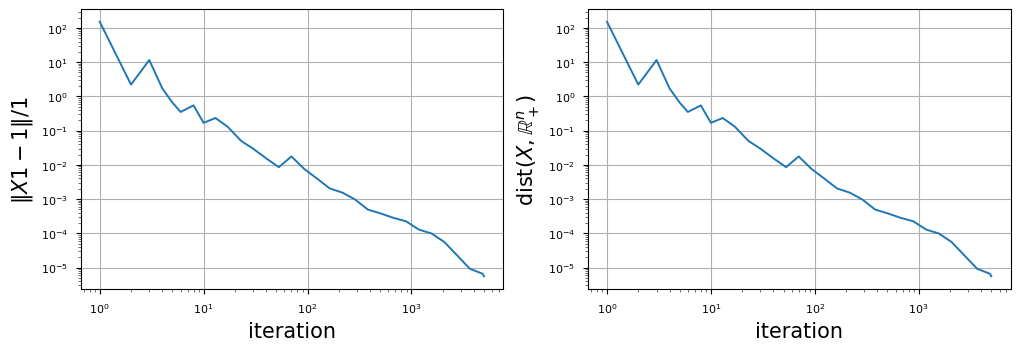

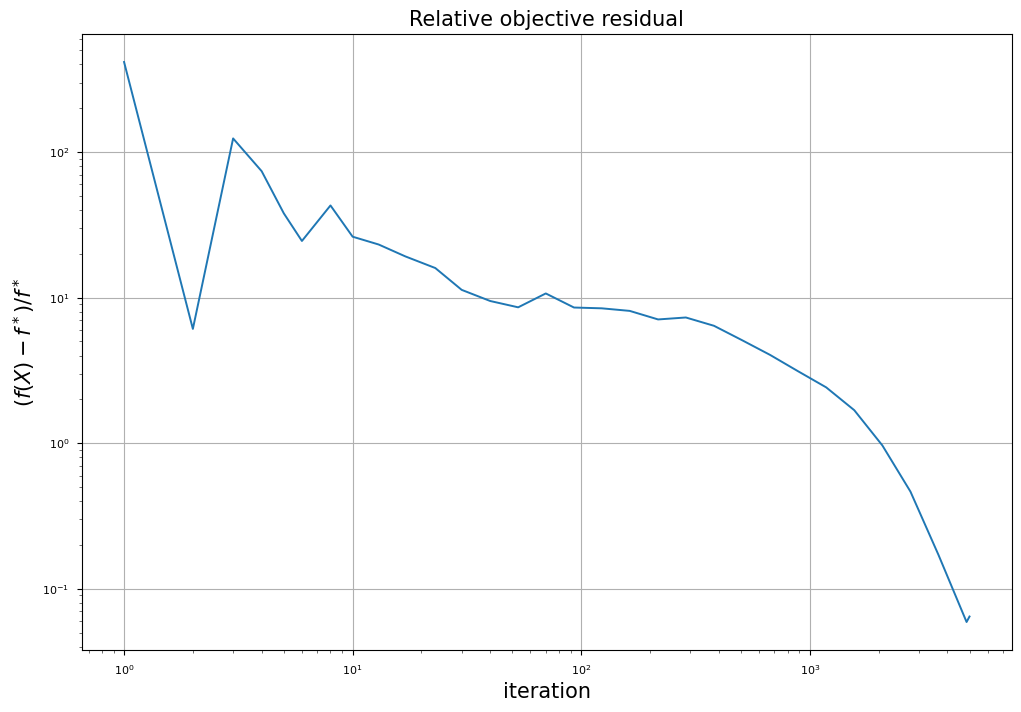

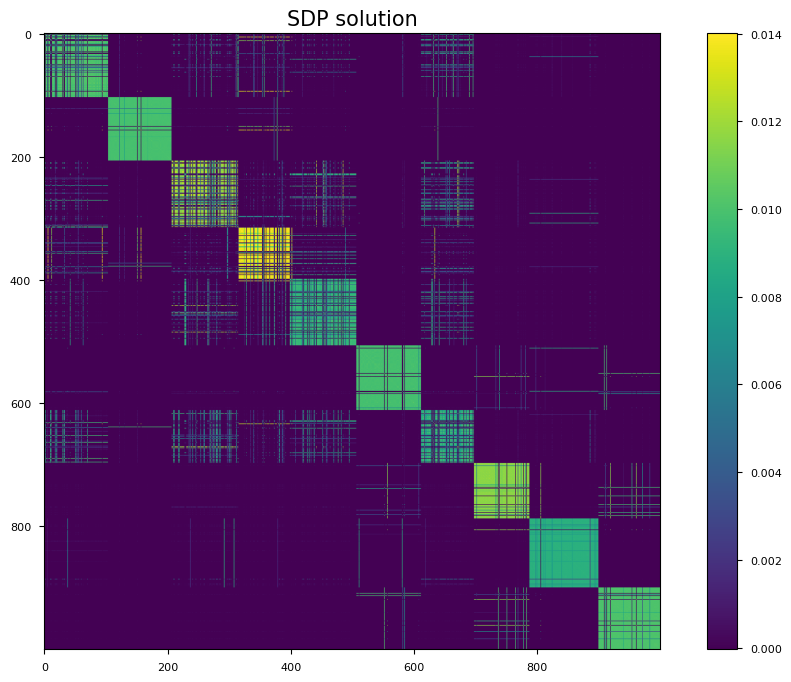

In [9]:
plot_func(iter_HCGM, f1_HCGM,f2_HCGM, obj_HCGM, X_HCGM, opt_val)

### Algorithm 2. PD3O splitting

To implement PD3O we need to specify the proximal operator of $h$ and $g^*$ as well as the linear operator $A$. We do so in the following cell. Note that the `DualVariable` class is created to keep track of all three dual variable $(y_1,y_2,y_3)$ in a concise way.
In the following cells fill in the proximal operators of $h$ and $g$.

**Hint**: Recall that the proximal operator of an indicator function is a projection. We give you the `projSDP`, which projects onto $\mathcal X$. Further, the proximal operator of a seperable sum is a concatenation of the proximal operators of each term (see the lecture on proximal methods).

In [10]:
f = Function(
    f = lambda X : np.sum(C.flatten()*X.flatten()),
    grad = lambda X : C
)

h = Function(
    f = lambda X : 0 if (ispsd(X) and np.trace(X) <= kappa) else float('inf') ,
    prox = lambda tau, X: projSDP(X, kappa)
)

g = Function(
    f = lambda y: 0 if (y.y_1==b) and (y.y_2==b) and (np.all(y.y_3 >=0)) else float('inf'),
    prox = lambda sigma, y: DualVariable(b, b, np.maximum(y.y_3, 0))
)

def A(x):
    return DualVariable(A1(x), A2(x), x)

def A_T(y):
    return At1(y.y_1)+ At2(y.y_2)+ y.y_3

composite = (f, g, h, A, A_T)

#### Question 2.2.3 (5 pts)

Complete the missing lines in the function
definitions of `PD3O` 

**Remarks:** 

- In our case, we advise you to **multiply the step-size for $y_3$ by $10^4$** to obtain a better practical convergence. It is possible to use different dual step sizes, $\{ \sigma_1 , \sigma_2, \sigma_3 \}$.  Such a diagonal variable stepsize is supported through `[sigma1, sigma2, sigma3]*dual_variable`.
- The algorithm needs the proximal operator of $g^*$, the Fenchel dual of $g$, using the Moreau identity express the prox of $g^*$ in terms of the prox of $g$. You will need to multiply by the stepsize `Sigma` and its inverse `Sigma_inv` which we provide in the code below.

In [11]:
@dataclass
class PD3O_state(OptState):
    x_k: Matrix
    y_k: DualVariable(Vector, Vector, Matrix)
    tau: float
    sigma: float

In [12]:
def PD3O_initialize(composite, x_zero):
    L = 1e2
    tau = 1/L
    return PD3O_state(x_k = x_zero, y_k = A(x_zero), tau=tau, sigma=1/(L**2*tau))

def PD3O_update(composite, state):
    f, g, h, A, A_T = composite
    y_k = state.y_k
    x_k, _, tau, sigma = state
    
    next_x_k = h.prox(tau, x_k - tau * f.grad(x_k) - tau * A_T(y_k))

    x_bar = 2 * next_x_k - x_k + tau * (f.grad(x_k) - f.grad(next_x_k))
    
    Sigma = [sigma, sigma, sigma*1e4]
    Sigma_inv = [1/sigma, 1/sigma, 1/(sigma*1e4)]

    u = y_k + Sigma * A(x_bar)
    u_scaled = Sigma_inv * u
    proj = g.prox(Sigma, u_scaled)

    next_y_k =  u - Sigma * proj
    
    return PD3O_state(next_x_k, next_y_k, tau, sigma)

In [13]:
PD3O = OptAlgorithm(name="PD3O", init_state = PD3O_initialize, state_update = PD3O_update)

#### Question 2.2.4 (2 pts) Run PD3O

Run `PD3O` for $1000$-iterations and plot the result.

In [14]:
X_PD3O, f1_PD3O, f2_PD3O, obj_PD3O, iter_PD3O, time_PD3O = run_PD3O(PD3O, composite, maxit=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

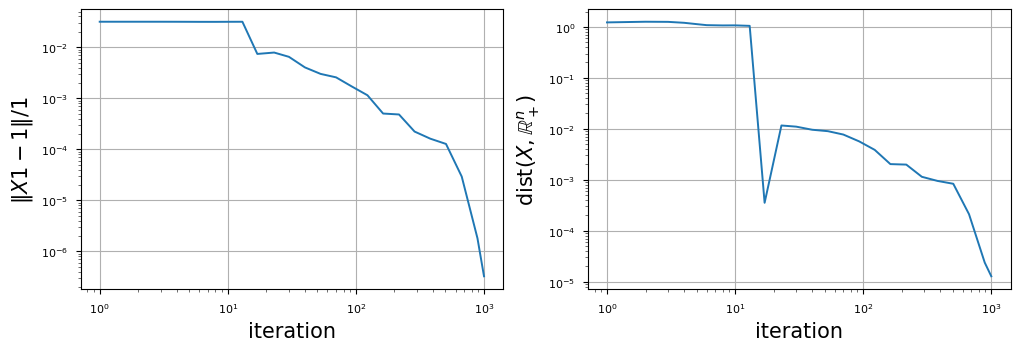

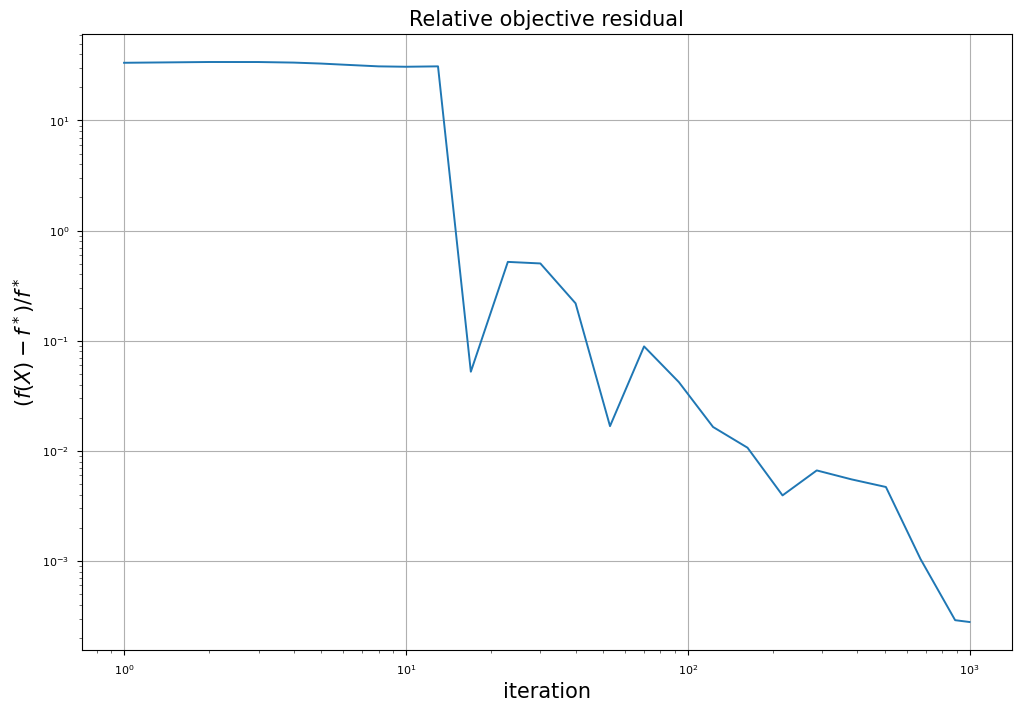

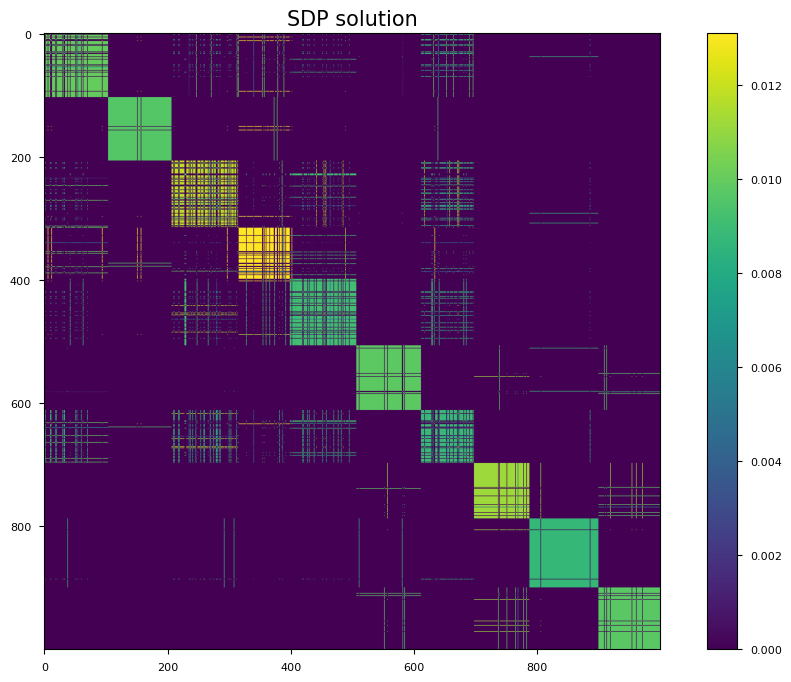

In [38]:
plot_func(iter_PD3O, f1_PD3O,f2_PD3O, obj_PD3O, X_PD3O, opt_val)

### Comparing HCGM and PD3O

#### Question 2.2.5 (3 pt)

Plot the results with the function `plot_comp`. What are the final objective values? Are they below the optimal value provided to you in `opt_val`? If yes, explain the reason. Answer in the box below.

[[-3.34314001e+01 -3.39780833e+01 -3.39625643e+01 -3.35651163e+01
  -3.28894991e+01 -3.21347741e+01 -3.10185786e+01 -3.07680840e+01
  -3.10258205e+01 -5.23246191e-02 -5.19925973e-01 -5.03299292e-01
  -2.18562933e-01 -1.67623389e-02 -8.87767010e-02  4.21142054e-02
  -1.64715507e-02 -1.06769438e-02 -3.93899957e-03 -6.64033501e-03
  -5.50913606e-03 -4.69542038e-03 -1.04119642e-03 -2.89826949e-04
  -2.78989108e-04]]
[[ 4.15988944e+02  6.10294469e+00  1.24175177e+02  7.39355697e+01
   3.79546829e+01  2.45226460e+01  4.30165259e+01  2.62401421e+01
   2.31875151e+01  1.92188779e+01  1.59830125e+01  1.13163397e+01
   9.48700747e+00  8.58610366e+00  1.06929941e+01  8.55783479e+00
   8.45052562e+00  8.11488223e+00  7.08798248e+00  7.31036061e+00
   6.41061917e+00  5.10912140e+00  4.04680868e+00  3.12251286e+00
   2.42040105e+00  1.68654711e+00  9.65984869e-01  4.65743625e-01
   1.70862497e-01 -5.91421461e-02 -6.45143230e-02]]


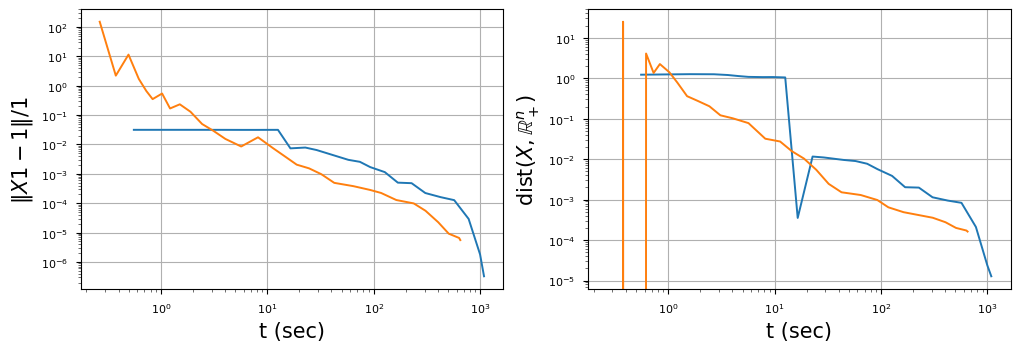

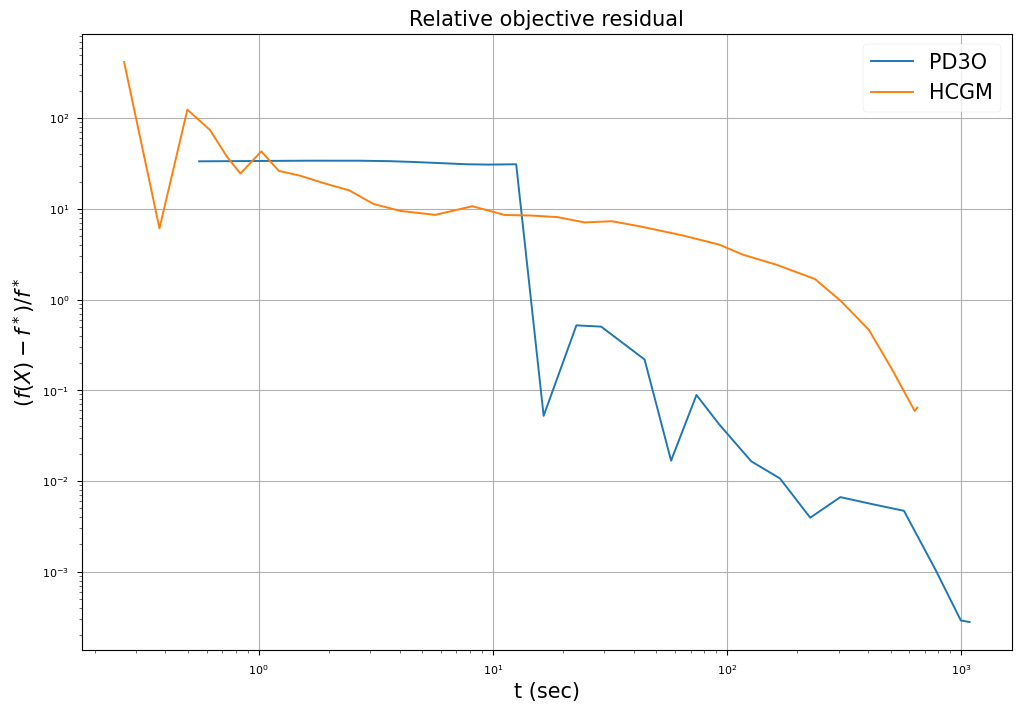

In [47]:
times = (time_PD3O, time_HCGM)
feas1 = (f1_PD3O, f1_HCGM)
feas2 = (f2_PD3O, f3_HCGM)
obj   = (obj_PD3O, obj_HCGM)

print((obj[0] - opt_val)/opt_val)
print((obj[1] - opt_val)/opt_val)

plot_comp(times, feas1,feas2, obj, opt_val)

<font color=‘blue’>
    
HCGM: The final relative residual for HCGm is around $10^{-1}$.

PD3O: The final relative residual for PD3O is lower than $10^{-3}$.

Yes, they are below the optimal value. Bacause HCGM and PD3O are solving a penalized relaxation of the problem, not the strictly constrained problem.

#### Rounding: Get the assignments from the result of the SDP
Getting the assignments requires going back to the $10$ dimensional space discussed before, and using the coordinates multiplied with the obtained matrix to construct a "denoised" version of the data points. This allows then to find the clusters from these $10$ dimensional data. Our implementation is the python reimplementation of their matlab code which can be found on [github](https://github.com/solevillar/kmeans_sdp).

In [43]:
center_HCGM, assign_HCGM = sdp_rounding(X_HCGM,10, digits)
center_PD3O, assign_PD3O = sdp_rounding(X_PD3O,10, digits)

#### k-means value: HCGM & PD3O

Using the function `value_kmeans`, run the cell below to obtain the $k$-means value before and after running both algorithms. 

    

In [17]:
k_means_before = value_kmeans(digits, labels-1) # k_means value with true labels
k_means_after_HCGM  = value_kmeans(digits, assign_HCGM) # k_means value with assigned lables
k_means_after_PD3O  = value_kmeans(digits, assign_PD3O) # k_means value with assigned lables

print('k-means value initial: {:.4f}'.format(k_means_before))
print('k-means value for HCGM: {:.4f}'.format(k_means_after_HCGM))
print('k-means value for PD3O: {:.4f}'.format(k_means_after_PD3O))

k-means value initial: 150.9680
k-means value for HCGM: 28.7269
k-means value for PD3O: 28.7269


#### Question 2.2.6 (3 pts) k-means value: Lloyd's algorithm

Run the function `kmeans` a few times and report the $k$-means value obtained by Llyod's algorithm. Compare it with the ones obtained by rounding the solution of convex methods `HCGM` and `PD3O`.  Comment on the result.

In [36]:
centers_Lloyd, classifications_Lloyd, k_means_Lloyd = kmeans(digits.T, 10)#k_means value with Lloyds k-means algorithm

print('k-means value for Lloyd''s algorithm: {:.4f}'.format(k_means_Lloyd))

k-means value for Lloyds algorithm: 161.1393


<font color=‘blue’>
    
k-means value for Lloyds algorithm: 202.7150, 307.4289, 161.1393

The k-means value obtained by Lloyd's algorithm is much more bigger than the ones obtained by rounding the solution of convex methods HCGM and PD3O. Because Lloyd's algorithm solves a non-convex problem and converges only to a local minimum, whereas the convex methods (HCGM and PD3O) solve a global optimization problem.

## OPTIONAL: Additional results for clustering fMNIST Data

### Misclassification rates: HCGM & PD3O


**Dataset:** We use the fashion-MNIST data in (Xiao et al. 2017) which is released as
a possible replacement for the MNIST handwritten digits . Each data
point is a 28x28 grayscale image, associated with a label from 10
classes. Classes
are labeled from 0 to 9. First, we extract the meaningful features from
this dataset using a simple 2 layers neural network with a sigmoid
activation. Then, we apply neural network to 1000 test samples from the
same dataset, which gives us a vector $\eta \in \mathbb{R}^{10}$ where
each entry represents the probability being in that class. Then, we form
the pairwise distance matrix $\boldsymbol{C}$ by using this probability
vectors (In the code, you do not need to worry about any of the processing
    details mentioned here. You are directly given the matrix
    $\mathbf{C}$.).

In [44]:
print('Misclassification rate for HCGM: {:.4f}'.format(misclassification_rate(assign_HCGM, labels)))
print('Misclassification rate for PD3O: {:.4f}'.format(misclassification_rate(assign_PD3O, labels)))

Misclassification rate for HCGM: 0.1250
Misclassification rate for PD3O: 0.1250


### Visualize samples and predicted labels

In [20]:
classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [21]:
def vis_samples(assignment, images, labels):
    assignment=assignment.astype(int)
    classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
    labels = labels-1
    rand_samp = np.random.randint(0,1000,25)
    plt.figure(figsize=(7,7))
    for i,samp in enumerate(rand_samp):
        plt.subplot(5,5,i+1)
        plt.imshow(1-np.reshape(images[samp],[28,28]), cmap=plt.cm.gray)
        plt.title('Pred. {0}\n Orig. {1}'.format(classes[assignment[samp].item()],classes[labels[samp].item()]))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

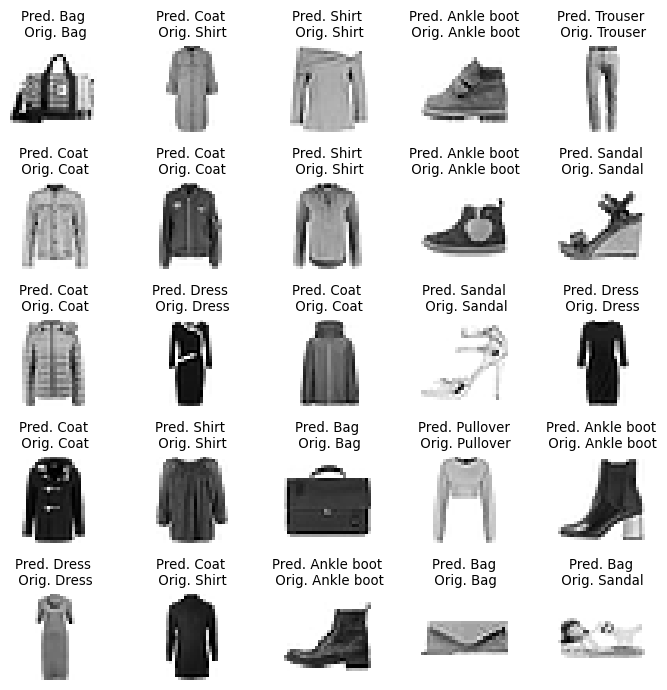

In [22]:
vis_samples(assign_HCGM, images,labels)

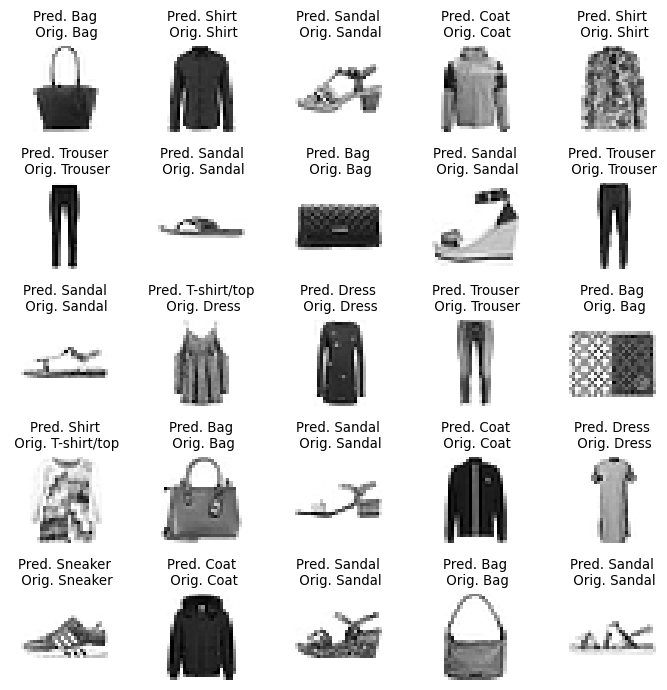

In [23]:
vis_samples(assign_PD3O, images,labels)

## References 

Xiao, Rasul & Vollgraf 2017,  Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms

Peng & Wei 2007, Approximating K-means-type clustering via semidefinite programming

Yurtsever, Fercoq, Locatello & Cevher 2018, A Conditional Gradient Framework for Composite Convex Minimization with Applications to Semidefinite Programming